# 09 — Observed Customer Value Analysis

## Objective

This notebook evaluates customer value observed during the available transaction period using:

- Delivered-order frequency
- Total recorded payment value
- Average order payment
- Customer purchasing span
- Repeat-purchase behavior
- Concentration of observed payment value

The analysis is historical and descriptive. It does not estimate future customer lifetime value, predict churn, or assume that customers remain inactive after the dataset ends.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

rfm_customers = pd.read_csv(
    DATA_DIR / "rfm_customer_segments.csv",
    parse_dates=[
        "snapshot_date",
        "first_order_date",
        "last_order_date"
    ]
)

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

print(
    "Customer records loaded:",
    f"{len(rfm_customers):,}"
)
print(
    "Order records loaded:",
    f"{len(order_analytics):,}"
)
print(
    "Observation period:",
    order_analytics["order_purchase_timestamp"].min().date(),
    "to",
    order_analytics["order_purchase_timestamp"].max().date()
)
print(
    "RFM snapshot date:",
    rfm_customers["snapshot_date"].max().date()
)

Customer records loaded: 93,357
Order records loaded: 99,441
Observation period: 2016-09-04 to 2018-10-17
RFM snapshot date: 2018-08-30


In [2]:
customer_value = rfm_customers.copy()

customer_value["repeat_customer"] = (
    customer_value["frequency"] > 1
)

customer_value["average_order_payment"] = (
    customer_value["monetary"]
    / customer_value["frequency"]
)

customer_value["additional_orders_after_first"] = (
    customer_value["frequency"] - 1
)

customer_value["purchase_span_days"] = (
    customer_value["last_order_date"].dt.normalize()
    - customer_value["first_order_date"].dt.normalize()
).dt.days

customer_value_summary = pd.DataFrame({
    "metric": [
        "Customers represented",
        "Delivered orders represented",
        "Observed payment value",
        "Average orders per customer",
        "One-time customers",
        "Repeat customers",
        "Repeat-customer rate",
        "Orders placed by repeat customers",
        "Repeat-customer order share",
        "Average observed payment per customer",
        "Median observed payment per customer",
        "Average payment per delivered order"
    ],
    "value": [
        len(customer_value),
        customer_value["frequency"].sum(),
        customer_value["monetary"].sum(),
        customer_value["frequency"].mean(),
        (~customer_value["repeat_customer"]).sum(),
        customer_value["repeat_customer"].sum(),
        customer_value["repeat_customer"].mean(),
        customer_value.loc[
            customer_value["repeat_customer"],
            "frequency"
        ].sum(),
        (
            customer_value.loc[
                customer_value["repeat_customer"],
                "frequency"
            ].sum()
            / customer_value["frequency"].sum()
        ),
        customer_value["monetary"].mean(),
        customer_value["monetary"].median(),
        (
            customer_value["monetary"].sum()
            / customer_value["frequency"].sum()
        )
    ]
})

display(
    customer_value_summary.style.format({
        "value": lambda value: (
            f"{value:,.2f}"
            if isinstance(value, (float, np.floating))
            else f"{value:,}"
        )
    })
)

print(
    "Observed payment total:",
    f"R$ {customer_value['monetary'].sum():,.2f}"
)

,metric,value
0,Customers represented,"93,357.00"
1,Delivered orders represented,"96,477.00"
2,Observed payment value,"15,422,461.77"
3,Average orders per customer,1.03
4,One-time customers,"90,556.00"
5,Repeat customers,"2,801.00"
6,Repeat-customer rate,0.03
7,Orders placed by repeat customers,"5,921.00"
8,Repeat-customer order share,0.06
9,Average observed payment per customer,165.20


Observed payment total: R$ 15,422,461.77


In [3]:
customer_value["customer_type"] = np.where(
    customer_value["repeat_customer"],
    "Repeat customer",
    "One-time customer"
)

customer_type_summary = (
    customer_value
    .groupby("customer_type", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        delivered_orders=("frequency", "sum"),
        observed_payment_value=("monetary", "sum"),
        average_payment_per_customer=("monetary", "mean"),
        median_payment_per_customer=("monetary", "median"),
        average_order_payment=("average_order_payment", "mean"),
        average_purchase_span_days=("purchase_span_days", "mean")
    )
)

customer_type_summary["customer_share"] = (
    customer_type_summary["customers"]
    / customer_type_summary["customers"].sum()
)

customer_type_summary["order_share"] = (
    customer_type_summary["delivered_orders"]
    / customer_type_summary["delivered_orders"].sum()
)

customer_type_summary["payment_share"] = (
    customer_type_summary["observed_payment_value"]
    / customer_type_summary["observed_payment_value"].sum()
)

customer_type_summary = (
    customer_type_summary
    .sort_values("customers", ascending=False)
    .reset_index(drop=True)
)

display(
    customer_type_summary.style.format({
        "customers": "{:,.0f}",
        "delivered_orders": "{:,.0f}",
        "observed_payment_value": "R$ {:,.2f}",
        "average_payment_per_customer": "R$ {:,.2f}",
        "median_payment_per_customer": "R$ {:,.2f}",
        "average_order_payment": "R$ {:,.2f}",
        "average_purchase_span_days": "{:,.1f}",
        "customer_share": "{:.2%}",
        "order_share": "{:.2%}",
        "payment_share": "{:.2%}"
    })
)

,customer_type,customers,delivered_orders,observed_payment_value,average_payment_per_customer,median_payment_per_customer,average_order_payment,average_purchase_span_days,customer_share,order_share,payment_share
0,One-time customer,"90,556","90,556","R$ 14,558,104.56",R$ 160.76,R$ 105.39,R$ 160.76,0.0,97.00%,93.86%,94.40%
1,Repeat customer,"2,801","5,921","R$ 864,357.21",R$ 308.59,R$ 225.55,R$ 145.87,88.2,3.00%,6.14%,5.60%


In [4]:
delivered_customer_orders = (
    order_analytics.loc[
        (order_analytics["order_status"] == "delivered")
        & order_analytics["customer_unique_id"].notna()
        & order_analytics["total_payment_value"].notna(),
        [
            "customer_unique_id",
            "order_id",
            "order_purchase_timestamp",
            "total_payment_value"
        ]
    ]
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp",
            "order_id"
        ]
    )
    .copy()
)

delivered_customer_orders["previous_purchase_timestamp"] = (
    delivered_customer_orders
    .groupby("customer_unique_id")[
        "order_purchase_timestamp"
    ]
    .shift()
)

delivered_customer_orders["days_since_previous_purchase"] = (
    delivered_customer_orders[
        "order_purchase_timestamp"
    ].dt.normalize()
    - delivered_customer_orders[
        "previous_purchase_timestamp"
    ].dt.normalize()
).dt.days

repeat_purchase_intervals = (
    delivered_customer_orders.loc[
        delivered_customer_orders[
            "days_since_previous_purchase"
        ].notna()
    ]
    .copy()
)

interval_summary = pd.DataFrame({
    "statistic": [
        "Observed repeat-purchase intervals",
        "Average days between purchases",
        "Median days between purchases",
        "25th percentile",
        "75th percentile",
        "90th percentile",
        "Maximum days between purchases"
    ],
    "value": [
        len(repeat_purchase_intervals),
        repeat_purchase_intervals[
            "days_since_previous_purchase"
        ].mean(),
        repeat_purchase_intervals[
            "days_since_previous_purchase"
        ].median(),
        repeat_purchase_intervals[
            "days_since_previous_purchase"
        ].quantile(0.25),
        repeat_purchase_intervals[
            "days_since_previous_purchase"
        ].quantile(0.75),
        repeat_purchase_intervals[
            "days_since_previous_purchase"
        ].quantile(0.90),
        repeat_purchase_intervals[
            "days_since_previous_purchase"
        ].max()
    ]
})

display(
    interval_summary.style.format({
        "value": "{:,.2f}"
    })
)

print(
    "Intervals represented:",
    f"{len(repeat_purchase_intervals):,}"
)
print(
    "Expected additional orders:",
    f"{customer_value['additional_orders_after_first'].sum():,}"
)

,statistic,value
0,Observed repeat-purchase intervals,"3,120.00"
1,Average days between purchases,79.15
2,Median days between purchases,29.00
3,25th percentile,0.00
4,75th percentile,122.00
5,90th percentile,240.10
6,Maximum days between purchases,609.00


Intervals represented: 3,120
Expected additional orders: 3,120


In [5]:
interval_bins = [-1, 0, 7, 30, 90, 180, np.inf]

interval_labels = [
    "Same day",
    "1–7 days",
    "8–30 days",
    "31–90 days",
    "91–180 days",
    "More than 180 days"
]

repeat_purchase_intervals["interval_group"] = pd.cut(
    repeat_purchase_intervals["days_since_previous_purchase"],
    bins=interval_bins,
    labels=interval_labels,
    ordered=True
)

interval_distribution = (
    repeat_purchase_intervals
    .groupby(
        "interval_group",
        observed=True,
        as_index=False
    )
    .agg(
        purchase_intervals=(
            "days_since_previous_purchase",
            "size"
        ),
        customers=(
            "customer_unique_id",
            "nunique"
        ),
        average_interval_days=(
            "days_since_previous_purchase",
            "mean"
        ),
        current_order_payment=(
            "total_payment_value",
            "sum"
        )
    )
)

interval_distribution["interval_share"] = (
    interval_distribution["purchase_intervals"]
    / interval_distribution["purchase_intervals"].sum()
)

display(
    interval_distribution.style.format({
        "purchase_intervals": "{:,.0f}",
        "customers": "{:,.0f}",
        "average_interval_days": "{:,.1f}",
        "current_order_payment": "R$ {:,.2f}",
        "interval_share": "{:.2%}"
    })
)

print(
    "Intervals represented:",
    f"{interval_distribution['purchase_intervals'].sum():,}"
)

,interval_group,purchase_intervals,customers,average_interval_days,current_order_payment,interval_share
0,Same day,890,854,0.0,"R$ 123,207.15",28.53%
1,1–7 days,233,229,3.7,"R$ 37,629.83",7.47%
2,8–30 days,445,424,17.4,"R$ 67,453.81",14.26%
3,31–90 days,581,558,55.9,"R$ 86,773.76",18.62%
4,91–180 days,462,452,132.1,"R$ 67,655.98",14.81%
5,More than 180 days,509,504,284.6,"R$ 72,726.46",16.31%


Intervals represented: 3,120


In [6]:
delivered_customer_orders["purchase_date"] = (
    delivered_customer_orders[
        "order_purchase_timestamp"
    ].dt.normalize()
)

customer_purchase_pattern = (
    delivered_customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        distinct_purchase_days=("purchase_date", "nunique"),
        observed_payment_value=("total_payment_value", "sum"),
        first_purchase_date=("purchase_date", "min"),
        last_purchase_date=("purchase_date", "max")
    )
)

customer_purchase_pattern["purchase_pattern"] = np.select(
    [
        customer_purchase_pattern["delivered_orders"] == 1,
        (
            (customer_purchase_pattern["delivered_orders"] > 1)
            & (
                customer_purchase_pattern[
                    "distinct_purchase_days"
                ] == 1
            )
        )
    ],
    [
        "One delivered order",
        "Multiple orders on one day"
    ],
    default="Orders across multiple days"
)

purchase_pattern_summary = (
    customer_purchase_pattern
    .groupby("purchase_pattern", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        delivered_orders=("delivered_orders", "sum"),
        observed_payment_value=("observed_payment_value", "sum"),
        average_orders_per_customer=("delivered_orders", "mean"),
        average_payment_per_customer=(
            "observed_payment_value",
            "mean"
        )
    )
)

purchase_pattern_summary["customer_share"] = (
    purchase_pattern_summary["customers"]
    / purchase_pattern_summary["customers"].sum()
)

purchase_pattern_summary["order_share"] = (
    purchase_pattern_summary["delivered_orders"]
    / purchase_pattern_summary["delivered_orders"].sum()
)

purchase_pattern_summary["payment_share"] = (
    purchase_pattern_summary["observed_payment_value"]
    / purchase_pattern_summary["observed_payment_value"].sum()
)

purchase_pattern_summary = (
    purchase_pattern_summary
    .sort_values("customers", ascending=False)
    .reset_index(drop=True)
)

display(
    purchase_pattern_summary.style.format({
        "customers": "{:,.0f}",
        "delivered_orders": "{:,.0f}",
        "observed_payment_value": "R$ {:,.2f}",
        "average_orders_per_customer": "{:.2f}",
        "average_payment_per_customer": "R$ {:,.2f}",
        "customer_share": "{:.2%}",
        "order_share": "{:.2%}",
        "payment_share": "{:.2%}"
    })
)

print(
    "Customers represented:",
    f"{purchase_pattern_summary['customers'].sum():,}"
)
print(
    "Expected customers:",
    f"{len(customer_value):,}"
)

,purchase_pattern,customers,delivered_orders,observed_payment_value,average_orders_per_customer,average_payment_per_customer,customer_share,order_share,payment_share
0,One delivered order,"90,556","90,556","R$ 14,558,104.56",1.00,R$ 160.76,97.00%,93.86%,94.40%
1,Orders across multiple days,"2,015","4,323","R$ 646,454.25",2.15,R$ 320.82,2.16%,4.48%,4.19%
2,Multiple orders on one day,786,"1,598","R$ 217,902.96",2.03,R$ 277.23,0.84%,1.66%,1.41%


Customers represented: 93,357
Expected customers: 93,357


In [7]:
value_ranked_customers = (
    customer_value
    .sort_values("monetary", ascending=False)
    .reset_index(drop=True)
    .copy()
)

value_ranked_customers["customer_rank"] = (
    np.arange(1, len(value_ranked_customers) + 1)
)

value_ranked_customers["cumulative_customer_share"] = (
    value_ranked_customers["customer_rank"]
    / len(value_ranked_customers)
)

value_ranked_customers["cumulative_payment_share"] = (
    value_ranked_customers["monetary"].cumsum()
    / value_ranked_customers["monetary"].sum()
)

concentration_levels = [
    ("Top 1%", 0.01),
    ("Top 5%", 0.05),
    ("Top 10%", 0.10),
    ("Top 20%", 0.20),
    ("Top 50%", 0.50)
]

concentration_records = []

for label, customer_share in concentration_levels:
    customer_count = int(
        np.ceil(
            len(value_ranked_customers)
            * customer_share
        )
    )

    selected_customers = (
        value_ranked_customers.iloc[:customer_count]
    )

    concentration_records.append({
        "customer_group": label,
        "customers": customer_count,
        "customer_share": (
            customer_count
            / len(value_ranked_customers)
        ),
        "minimum_observed_payment": (
            selected_customers["monetary"].min()
        ),
        "observed_payment_value": (
            selected_customers["monetary"].sum()
        ),
        "payment_share": (
            selected_customers["monetary"].sum()
            / value_ranked_customers["monetary"].sum()
        )
    })

payment_concentration = pd.DataFrame(
    concentration_records
)

display(
    payment_concentration.style.format({
        "customers": "{:,.0f}",
        "customer_share": "{:.2%}",
        "minimum_observed_payment": "R$ {:,.2f}",
        "observed_payment_value": "R$ {:,.2f}",
        "payment_share": "{:.2%}"
    })
)

,customer_group,customers,customer_share,minimum_observed_payment,observed_payment_value,payment_share
0,Top 1%,934,1.00%,"R$ 1,097.17","R$ 1,596,180.66",10.35%
1,Top 5%,"4,668",5.00%,R$ 469.71,"R$ 4,132,560.57",26.80%
2,Top 10%,"9,336",10.00%,R$ 318.13,"R$ 5,899,278.13",38.25%
3,Top 20%,"18,672",20.00%,R$ 208.55,"R$ 8,254,874.14",53.53%
4,Top 50%,"46,679",50.00%,R$ 107.78,"R$ 12,455,005.74",80.76%


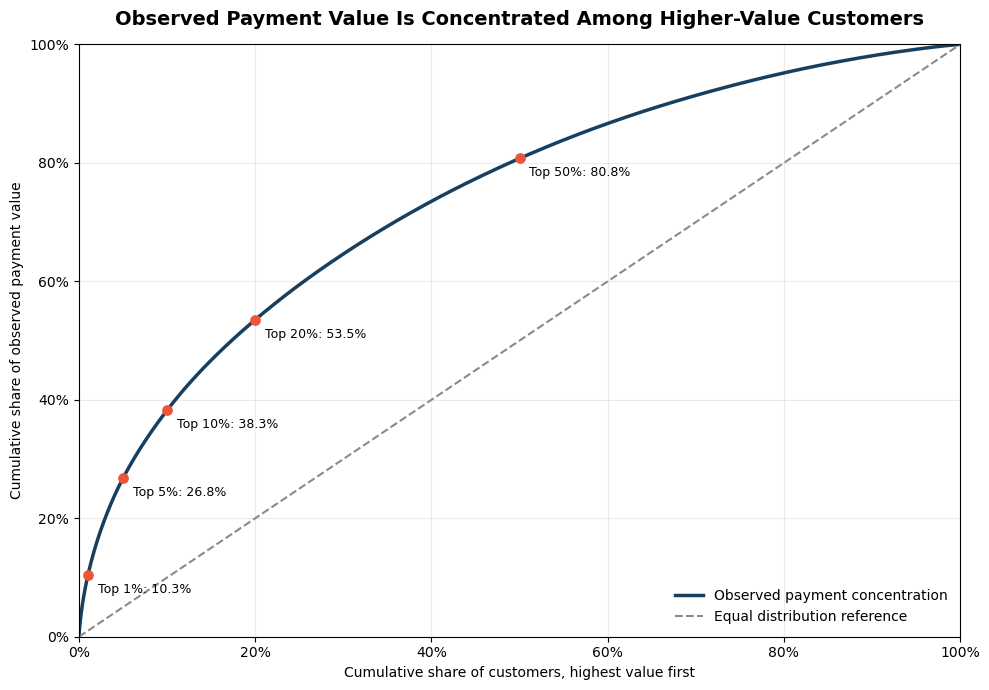

In [8]:
curve_x = np.concatenate([
    [0],
    value_ranked_customers[
        "cumulative_customer_share"
    ].to_numpy()
])

curve_y = np.concatenate([
    [0],
    value_ranked_customers[
        "cumulative_payment_share"
    ].to_numpy()
])

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    curve_x,
    curve_y,
    color=COLORS["primary"],
    linewidth=2.5,
    label="Observed payment concentration"
)

ax.plot(
    [0, 1],
    [0, 1],
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1.5,
    label="Equal distribution reference"
)

for _, row in payment_concentration.iterrows():
    ax.scatter(
        row["customer_share"],
        row["payment_share"],
        color=COLORS["negative"],
        s=45,
        zorder=3
    )

    ax.annotate(
        (
            f"{row['customer_group']}: "
            f"{row['payment_share']:.1%}"
        ),
        xy=(
            row["customer_share"],
            row["payment_share"]
        ),
        xytext=(7, -13),
        textcoords="offset points",
        fontsize=9
    )

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel("Cumulative share of customers, highest value first")
ax.set_ylabel("Cumulative share of observed payment value")

ax.set_title(
    "Observed Payment Value Is Concentrated Among Higher-Value Customers",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "observed_payment_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** When customers are ranked by observed delivered-payment value, the top 10% account for 38.25% of value and the top 20% account for 53.53%. This measures historical payment concentration within the dataset and does not represent predicted customer lifetime value.

In [9]:
final_validation = pd.DataFrame([
    {
        "validation_check": "Customer rows represented",
        "result": len(customer_value),
        "expected": 93_357
    },
    {
        "validation_check": "Duplicate customer IDs",
        "result": customer_value[
            "customer_unique_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Delivered orders represented",
        "result": customer_value["frequency"].sum(),
        "expected": 96_477
    },
    {
        "validation_check": "Observed payment value represented",
        "result": round(
            customer_value["monetary"].sum(),
            2
        ),
        "expected": round(
            delivered_customer_orders[
                "total_payment_value"
            ].sum(),
            2
        )
    },
    {
        "validation_check": "Purchase-pattern customers represented",
        "result": purchase_pattern_summary[
            "customers"
        ].sum(),
        "expected": len(customer_value)
    },
    {
        "validation_check": "Repeat-purchase intervals represented",
        "result": len(repeat_purchase_intervals),
        "expected": customer_value[
            "additional_orders_after_first"
        ].sum()
    },
    {
        "validation_check": "Negative observed payment values",
        "result": (
            customer_value["monetary"] < 0
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Final cumulative payment share",
        "result": round(
            value_ranked_customers[
                "cumulative_payment_share"
            ].iloc[-1],
            6
        ),
        "expected": 1.0
    }
])

final_validation["status"] = np.where(
    final_validation["result"]
    == final_validation["expected"],
    "Passed",
    "Failed"
)

display(final_validation)

,validation_check,result,expected,status
0,Customer rows represented,"93,357.00","93,357.00",Passed
1,Duplicate customer IDs,0.00,0.00,Passed
2,Delivered orders represented,"96,477.00","96,477.00",Passed
3,Observed payment value represented,"15,422,461.77","15,422,461.77",Passed
4,Purchase-pattern customers represented,"93,357.00","93,357.00",Passed
5,Repeat-purchase intervals represented,"3,120.00","3,120.00",Passed
6,Negative observed payment values,0.00,0.00,Passed
7,Final cumulative payment share,1.00,1.00,Passed


In [10]:
export_files = {
    "observed_customer_value.csv": customer_value,
    "customer_type_value_summary.csv": customer_type_summary,
    "repeat_purchase_intervals.csv": repeat_purchase_intervals,
    "repeat_interval_distribution.csv": interval_distribution,
    "customer_purchase_patterns.csv": purchase_pattern_summary,
    "observed_payment_concentration.csv": payment_concentration,
    "customer_value_validation_report.csv": final_validation
}

for filename, dataframe in export_files.items():
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in export_files
)

print(
    "Customer-value files exported:",
    len(export_files)
)
print(
    "All customer-value files created:",
    all_files_created
)

Customer-value files exported: 7
All customer-value files created: True


## Conclusion

***Key findings:***

- The analysis represents 93,357 customers, 96,477 delivered orders, and R$15.42 million in observed payment value.
- Only 3.00% of customers placed multiple delivered orders, accounting for 6.14% of delivered orders and 5.60% of payment value.
- Only 2.16% of customers purchased across multiple calendar days; another 0.84% placed multiple orders on the same day.
- The median observed repeat-purchase interval is 29 days, although intervals vary substantially.
- The top 10% of customers account for 38.25% of observed payment value, while the top 20% account for 53.53%.
- Repeat customers have higher total observed payment per customer but lower average payment per order than one-time customers.

***Interpretation:*** These results describe customer value and purchasing behavior observed within the dataset. They do not predict future purchases, demonstrate loyalty or churn, or estimate customer lifetime value beyond the observation period.

***Outputs:*** Customer-level value metrics, purchase-pattern summaries, repeat-purchase intervals, payment-concentration results, and validation checks were exported for reporting.